In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx

# 1. LOAD DATA
info_raw = pd.read_csv('../data/merged/typhoon-info-infra-project.csv')
impact_raw = pd.read_csv('../data/merged/cleaned_typhoon_impacts.csv')

# 2. AGGREGATE INFO DATA 
# We group by Region and Year to capture the context of the disasters.
info_agg = info_raw.groupby(['Region', 'Year'], as_index=False).agg({
    'Max 24-hour Rainfall (mm)': 'max',
    'Peak Gust (10 mins sustained) (m/s)': 'max',
    'Cumulative_Budget_To_Date': 'sum',
    'Variance_Ratio_To_Date': 'mean'
})

# 3. MERGE
# This results in a dataset where each row is a regional disaster profile.
df = impact_raw.merge(info_agg, on=['Region', 'Year'], how='inner')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Cyclone Name                             283 non-null    object 
 1   Region                                   283 non-null    object 
 2   Year                                     283 non-null    int64  
 3   Category                                 283 non-null    object 
 4   Deaths                                   283 non-null    int64  
 5   Injuries                                 283 non-null    int64  
 6   Affected                                 283 non-null    int64  
 7   Houses destroyed                         283 non-null    int64  
 8   Houses damaged                           283 non-null    int64  
 9   Total Houses                             283 non-null    int64  
 10  Damage to Infrastructure (PhP)           283 non-n

In [10]:
df.head(15)

,Cyclone Name,Region,Year,Category,Deaths,Injuries,Affected,Houses destroyed,Houses damaged,Total Houses,Damage to Infrastructure (PhP),Damage to Agriculture + Fisheries (PhP),Max 24-hour Rainfall (mm),Peak Gust (10 mins sustained) (m/s),Cumulative_Budget_To_Date,Variance_Ratio_To_Date
0,Falcon,Region I,2019,Tropical Storm,0,0,5,0,1,1,9.140000e+08,0.000000e+00,471.8,21.666667,0.0,0.0
1,Falcon,Region II,2019,Tropical Storm,0,0,502,0,0,0,1.188795e+08,3.655604e+07,366.6,30.000000,0.0,0.0
2,Marilyn,Region II,2019,Tropical Depression,0,0,0,0,0,0,0.000000e+00,0.000000e+00,366.6,30.000000,0.0,0.0
3,Marilyn,Region III,2019,Tropical Depression,0,0,0,0,0,0,0.000000e+00,0.000000e+00,231.5,0.000000,0.0,0.0
4,Marilyn,Region VI,2019,Tropical Depression,0,0,0,0,0,0,0.000000e+00,0.000000e+00,155.0,43.000000,0.0,0.0
5,Tino,Region I,2019,Typhoon,0,0,521,0,0,0,0.000000e+00,0.000000e+00,471.8,21.666667,0.0,0.0
6,Tino,Region II,2019,Typhoon,0,0,20213,0,0,0,0.000000e+00,3.568939e+07,366.6,30.000000,0.0,0.0
7,Tino,Region V,2019,Typhoon,0,0,3290,10,9,19,0.000000e+00,0.000000e+00,298.8,40.000000,0.0,0.0
8,Tisoy,Region III,2019,Super Typhoon,0,0,21993,1,120,121,0.000000e+00,0.000000e+00,231.5,0.000000,0.0,0.0
9,Tisoy,Region IV-A,2019,Super Typhoon,3,0,116214,9108,1202,10310,0.000000e+00,6.683203e+08,111.4,13.500000,0.0,0.0


In [11]:

# 4. DISCRETIZATION (The core of "Quantitative" ARM)
def discretize_data(data):
    df_bins = pd.DataFrame()
    
    # We use the median as a threshold for 'High' vs 'Low'
    df_bins['Rain_High'] = data['Max 24-hour Rainfall (mm)'] > data['Max 24-hour Rainfall (mm)'].median()
    df_bins['Budget_Low'] = data['Cumulative_Budget_To_Date'] < data['Cumulative_Budget_To_Date'].median()
    df_bins['Inefficient_Spending'] = data['Variance_Ratio_To_Date'] > data['Variance_Ratio_To_Date'].median()
    
    # Targets
    df_bins['Outcome_High_Mortality'] = data['Deaths'] > data['Deaths'].median()
    df_bins['Outcome_High_Damage'] = data['Damage to Infrastructure (PhP)'] > data['Damage to Infrastructure (PhP)'].median()
    
    return df_bins

df_mining = discretize_data(df)

# 5. GENERATE FREQUENT ITEMSETS
# Lowering support to 0.01 (1%) because severe disasters are relatively rare 
# but important to capture.
frequent_itemsets = apriori(df_mining, min_support=0.01, use_colnames=True)

# 6. GENERATE RULES
# Lowering confidence to 0.2 (20%). In social science/disaster data, 
# a 20-30% confidence is often considered a significant pattern.
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.1)

# 7. FILTER FOR YOUR RESEARCH QUESTION
target_rules = rules[rules['consequents'].apply(lambda x: any('Outcome' in item for item in x))]
target_rules = target_rules.sort_values(by='lift', ascending=False)

print(f"Success! Found {len(target_rules)} rules.")
# 8. RESULTS
print(f"Total Transactions: {len(df_mining)}")
print(f"Rules Found: {len(target_rules)}")
print("\nTop Rules for Disaster Outcomes:")
print(target_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

# Export for your report
target_rules.to_csv('typhoon_association_rules.csv', index=False)

Success! Found 69 rules.
Total Transactions: 283
Rules Found: 69

Top Rules for Disaster Outcomes:
                                          antecedents  \
86  (Budget_Low, Inefficient_Spending, Outcome_Hig...   
87                (Outcome_High_Mortality, Rain_High)   
90                   (Outcome_High_Damage, Rain_High)   
83  (Outcome_High_Mortality, Budget_Low, Inefficie...   
39                 (Inefficient_Spending, Budget_Low)   
64                (Outcome_High_Mortality, Rain_High)   
65        (Inefficient_Spending, Outcome_High_Damage)   
80  (Budget_Low, Inefficient_Spending, Outcome_Hig...   
93                           (Outcome_High_Mortality)   
67                   (Outcome_High_Damage, Rain_High)   

                                          consequents   support  confidence  \
86                (Outcome_High_Mortality, Rain_High)  0.010601    0.375000   
87  (Budget_Low, Inefficient_Spending, Outcome_Hig...  0.010601    0.103448   
90  (Outcome_High_Mortality, Budget_

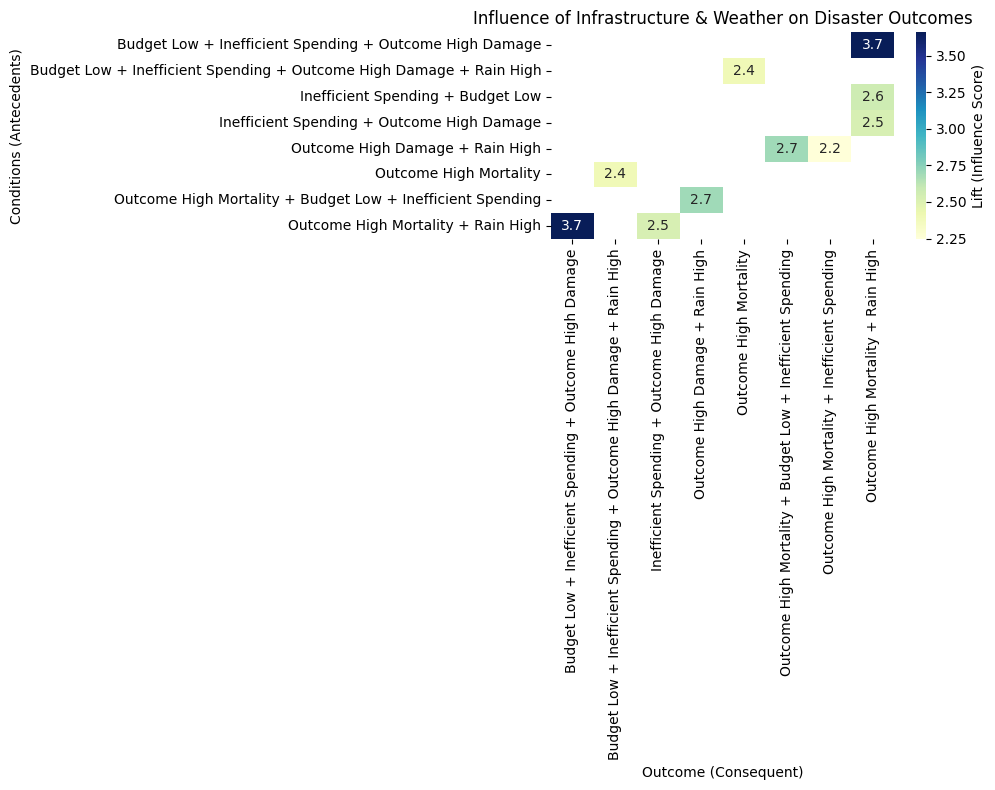

In [12]:
def plot_rule_heatmap(rules_df):
    if rules_df.empty:
        print("No rules to plot! Try lowering min_support or confidence thresholds.")
        return

    # Prepare data: Pivot rules for heatmap
    # Using top 15 rules for clarity
    top_rules = target_rules.nlargest(10, 'lift')
    top_rules['antecedents_str'] = top_rules['antecedents'].apply(lambda x: ' + '.join([i.replace('_', ' ') for i in x]))
    top_rules['consequents_str'] = top_rules['consequents'].apply(lambda x: ' + '.join([i.replace('_', ' ') for i in x]))
    
    pivot = top_rules.pivot(index='antecedents_str', columns='consequents_str', values='lift')

    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Lift (Influence Score)'})
    plt.title("Influence of Infrastructure & Weather on Disaster Outcomes")
    plt.xlabel("Outcome (Consequent)")
    plt.ylabel("Conditions (Antecedents)")
    plt.tight_layout()
    plt.show()

plot_rule_heatmap(target_rules)

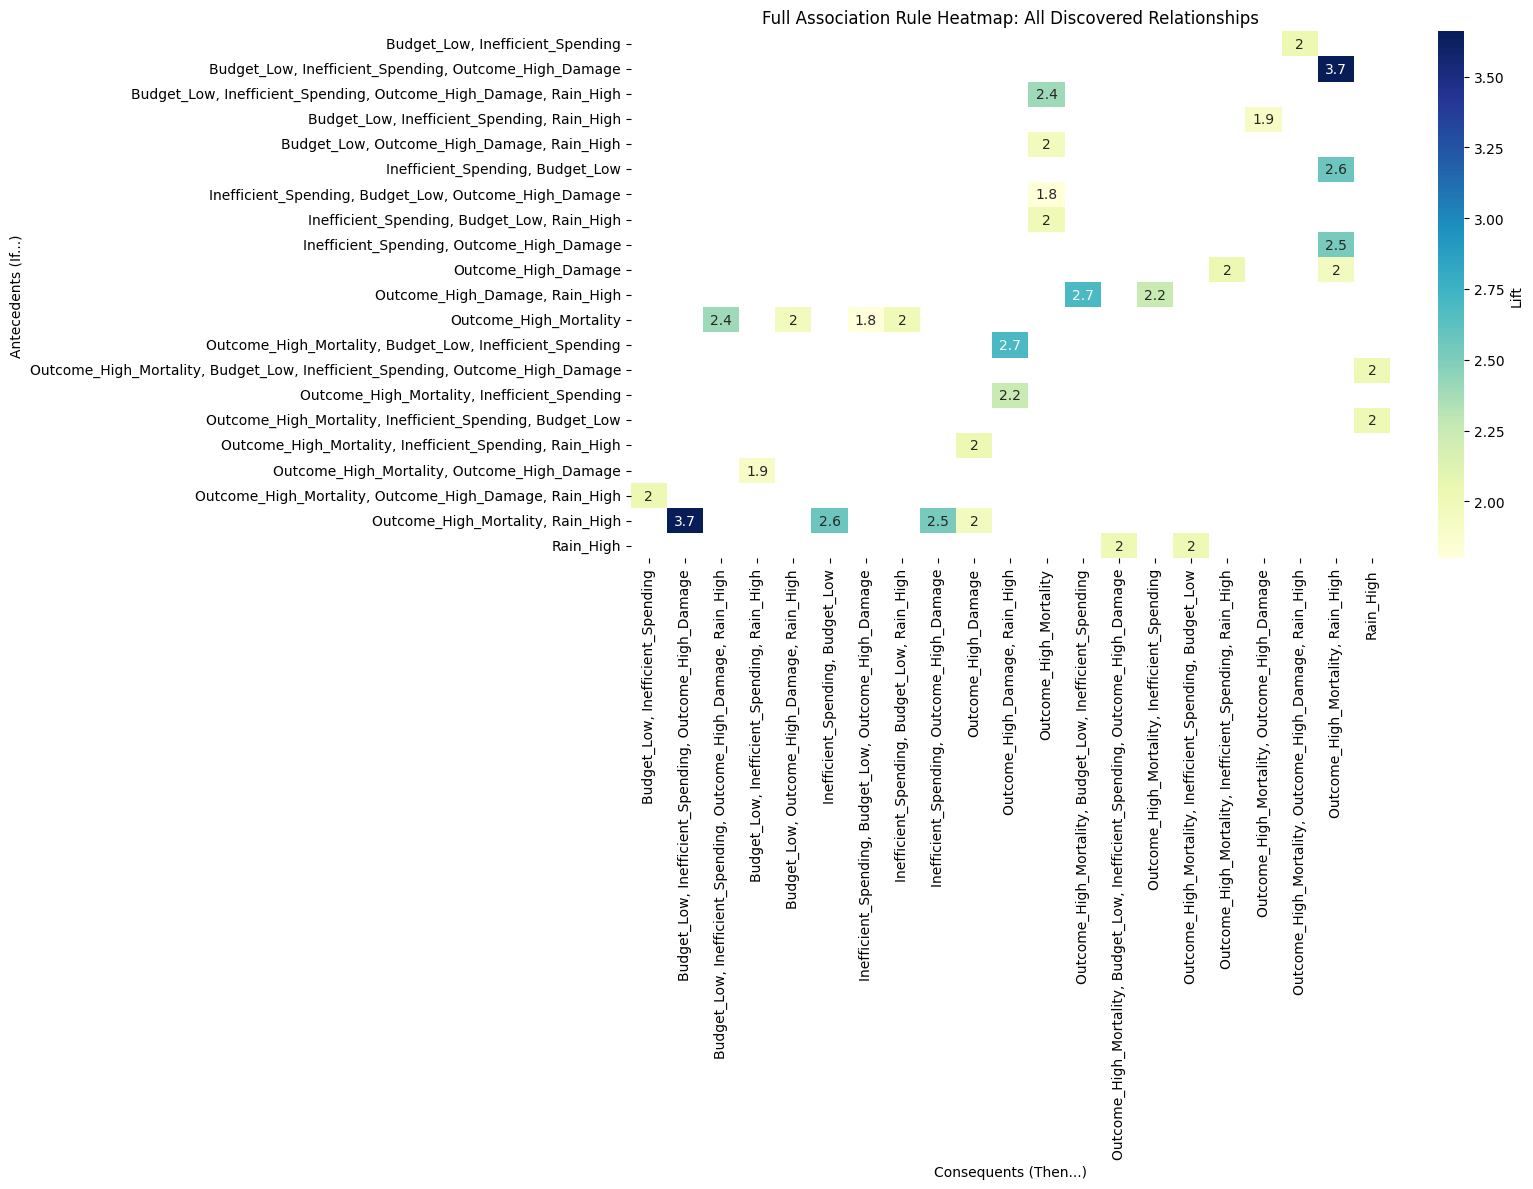

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_all_rules_heatmap(rules_df):
    if rules_df.empty:
        print("No rules found. Try lowering thresholds.")
        return

    # Use 'rules' (unfiltered) instead of 'target_rules'
    # We take the top 30 rules by Lift to keep the text readable
    plot_data = rules_df.sort_values('lift', ascending=False).head(30).copy()
    
    plot_data['antecedents_str'] = plot_data['antecedents'].apply(lambda x: ', '.join(list(x)))
    plot_data['consequents_str'] = plot_data['consequents'].apply(lambda x: ', '.join(list(x)))
    
    pivot = plot_data.pivot(index='antecedents_str', columns='consequents_str', values='lift')

    plt.figure(figsize=(16, 12))
    sns.heatmap(pivot, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Lift'})
    plt.title("Full Association Rule Heatmap: All Discovered Relationships")
    plt.xlabel("Consequents (Then...)")
    plt.ylabel("Antecedents (If...)")
    plt.tight_layout()
    plt.show()

# Run this using your 'rules' variable from Step 6
plot_all_rules_heatmap(rules)

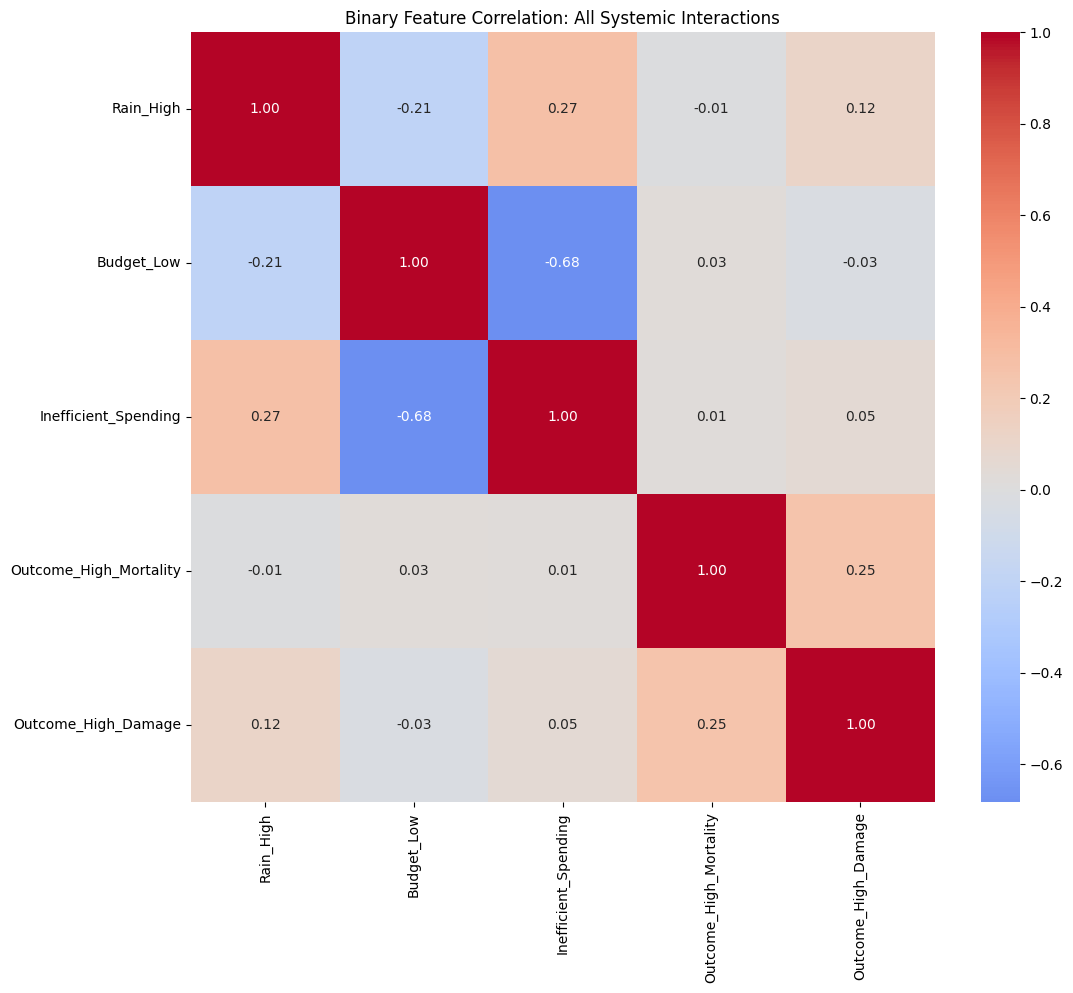

In [14]:
# This visualizes the relationships between ALL binned categories at once
plt.figure(figsize=(12, 10))
binary_corr = df_mining.corr()

# We use a 'coolwarm' map where Red = Positive Correlation, Blue = Negative
sns.heatmap(binary_corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Binary Feature Correlation: All Systemic Interactions")
plt.show()

In [20]:
def visualize_rules_network(rules_df, top_n=10):
    # 1. Prune the rules to avoid a "hairball" graph
    # We take the top N rules by Lift to show the most significant influences
    plot_rules = rules_df.nlargest(top_n, 'lift')
    
    G = nx.DiGraph()
    
    # 2. Build the graph
    # Nodes can be 'Items' (Rain_High) or 'Rule Nodes'
    for i, row in plot_rules.iterrows():
        rule_node = f"Rule {i}"
        G.add_node(rule_node, label='Rule', color='yellow')
        
        # Connect Antecedents to the Rule Node
        for ant in row['antecedents']:
            G.add_edge(ant, rule_node, weight=row['lift'])
            
        # Connect the Rule Node to Consequents
        for cons in row['consequents']:
            G.add_edge(rule_node, cons, weight=row['lift'])

    # 3. Positioning and Layout
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.8) # k controls the distance between nodes
    
    # 4. Draw Nodes
    # Color logic: Outcomes are Red, Factors are Skyblue, Rules are Yellow
    node_colors = []
    for node in G.nodes():
        if 'Outcome' in str(node):
            node_colors.append('#ff9999') # Soft Red
        elif 'Rule' in str(node):
            node_colors.append('#ffff99') # Yellow
        else:
            node_colors.append('#99ccff') # Sky Blue

    nx.draw_networkx_nodes(G, pos, node_size=2500, node_color=node_colors, alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
    
    # 5. Draw Edges (Thickness based on Lift)
    edges = G.edges(data=True)
    weights = [edge[2]['weight'] for edge in edges]
    
    nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', 
                           arrowstyle='->', arrowsize=20)

    plt.title(f"Network Graph: Top {top_n} Influential Rules (Lift-Weighted)")
    plt.axis('off')
    plt.show()

# Run the function
visualize_rules_network(target_rules, top_n=10)

NameError: name 'rule_label' is not defined